# S5 — Visualising RNA-seq results

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/enriquea/ZebraQ/blob/main/lessons-py/S5_PyDESeq2_Visualization.ipynb)

**ZebraQ — Introduction to Python and bulk RNA-seq data analysis**

A results table with 13,000 rows is not an answer. This notebook builds the five
figures that turn it into one: a single-gene plot, an expression heatmap, a
sample-distance heatmap, a PCA, and a volcano plot.

> **This notebook is self-contained.** It re-runs the model from the raw counts
> rather than loading a saved object from S4. Re-fitting takes a few seconds on
> this dataset, and it means you can open this notebook on its own — in Colab,
> for example — without having run S4 first.
>
> The R track saves `dds.rds` in S4 and loads it in S5. We deliberately do not
> do that: saved Python objects break when library versions change, which is a
> bad thing to hand to students.

## 0. Setup

In [1]:
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         # Pinned: this lesson relies on 0.5.x layer names (vst_counts) and
         # on size factors living in dds.obs.
         "pydeseq2==0.5.4", "seaborn", "scikit-learn", "adjustText", "session-info"],
        check=True,
    )

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

REPO_RAW = "https://raw.githubusercontent.com/enriquea/ZebraQ/main/"


def repo_path(relpath):
    local = Path("..") / relpath
    return local if local.exists() else REPO_RAW + relpath


sns.set_theme(style="white")
plt.rcParams["figure.dpi"] = 110
# PyDESeq2's built-in plots (plot_MA in section 8) are hardcoded to 600 dpi, which
# would embed a multi-megabyte image for no visible benefit. Cap it.
%config InlineBackend.print_figure_kwargs = {"dpi": 100, "bbox_inches": "tight"}

REFERENCE, TREATMENT, ALPHA = "WT", "MT", 0.05

## 1. Re-run the S4 analysis

Exactly the same steps as S4, collapsed into one cell.

In [2]:
metadata = pd.read_csv(repo_path("data/samplesheet.tsv"), sep="\t").set_index("sample_id")

counts = pd.read_csv(
    repo_path("data/salmon.merged.gene_counts.filtered.tsv"), sep="\t"
).set_index("gene_id")
counts = counts[metadata.index].astype(int)      # truncate, matching R

counts_t = counts.T                               # samples x genes for PyDESeq2
counts_t = counts_t.loc[:, counts_t.sum(axis=0) >= 10]

dds = DeseqDataSet(counts=counts_t, metadata=metadata, design="~condition", quiet=True)
dds.deseq2()

stat_res = DeseqStats(dds, contrast=["condition", TREATMENT, REFERENCE],
                      alpha=ALPHA, quiet=True)
stat_res.summary()
results = stat_res.results_df.copy()
results.index.name = "gene"

print(f"{results.shape[0]:,} genes tested, "
      f"{(results['padj'] < ALPHA).sum():,} significant at padj < {ALPHA}")

13,755 genes tested, 5,689 significant at padj < 0.05


## 2. Normalised counts and the variance-stabilising transform

Raw counts cannot be compared between samples with different sequencing depths,
so we use **normalised counts**.

For plotting we go one step further with the **variance-stabilising transform
(VST)**. In count data the variance grows with the mean, so highly expressed
genes dominate every distance calculation and every heatmap. VST puts all genes
on a comparable footing. Use VST for heatmaps, clustering and PCA — never for
the statistical test itself, which needs the raw counts.

In [3]:
normed = pd.DataFrame(
    dds.layers["normed_counts"], index=dds.obs_names, columns=dds.var_names
)

dds.vst()
vst = pd.DataFrame(dds.layers["vst_counts"], index=dds.obs_names, columns=dds.var_names)

print(f"normalised counts : {normed.shape}  range {normed.values.min():.1f} to {normed.values.max():,.0f}")
print(f"VST counts        : {vst.shape}  range {vst.values.min():.2f} to {vst.values.max():.2f}")
print("\nNotice how VST compresses the range — that is the point.")

normalised counts : (6, 13755)  range 0.0 to 1,636,292
VST counts        : (6, 13755)  range 5.38 to 20.64

Notice how VST compresses the range — that is the point.


## 3. One gene at a time

Before any global figure, look at a single gene. `capzb` is a strong hit here.

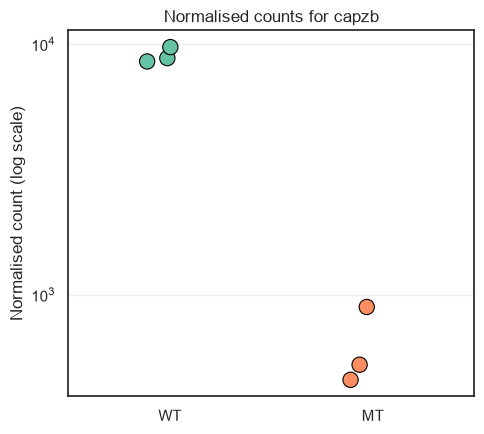

capzb: log2FC = -3.845, padj = 1.240e-61
  -> expression is 14.4x lower in MT


In [4]:
GENE = "capzb"

gene_df = pd.DataFrame({
    "count": normed[GENE],
    "condition": metadata.loc[normed.index, "condition"],
})

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.stripplot(data=gene_df, x="condition", y="count", hue="condition",
              order=[REFERENCE, TREATMENT], palette="Set2",
              size=11, jitter=0.12, legend=False, edgecolor="black",
              linewidth=0.8, ax=ax)
ax.set_yscale("log")
ax.set(title=f"Normalised counts for {GENE}", xlabel="", ylabel="Normalised count (log scale)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

row = results.loc[GENE]
print(f"{GENE}: log2FC = {row['log2FoldChange']:.3f}, padj = {row['padj']:.3e}")
print(f"  -> expression is {2 ** abs(row['log2FoldChange']):.1f}x "
      f"{'lower' if row['log2FoldChange'] < 0 else 'higher'} in {TREATMENT}")

## 4. Heatmap of the most variable genes

The R lesson picks the top 20 genes by **mean** expression. Ranking by
**variance** is usually more informative — the genes that differ between samples
are the ones that tell you about your experiment. We show both.

In [5]:
top_mean = normed.mean(axis=0).nlargest(20).index
top_var = vst.var(axis=0).nlargest(20).index

print(f"genes in both lists: {len(set(top_mean) & set(top_var))} of 20")

genes in both lists: 1 of 20


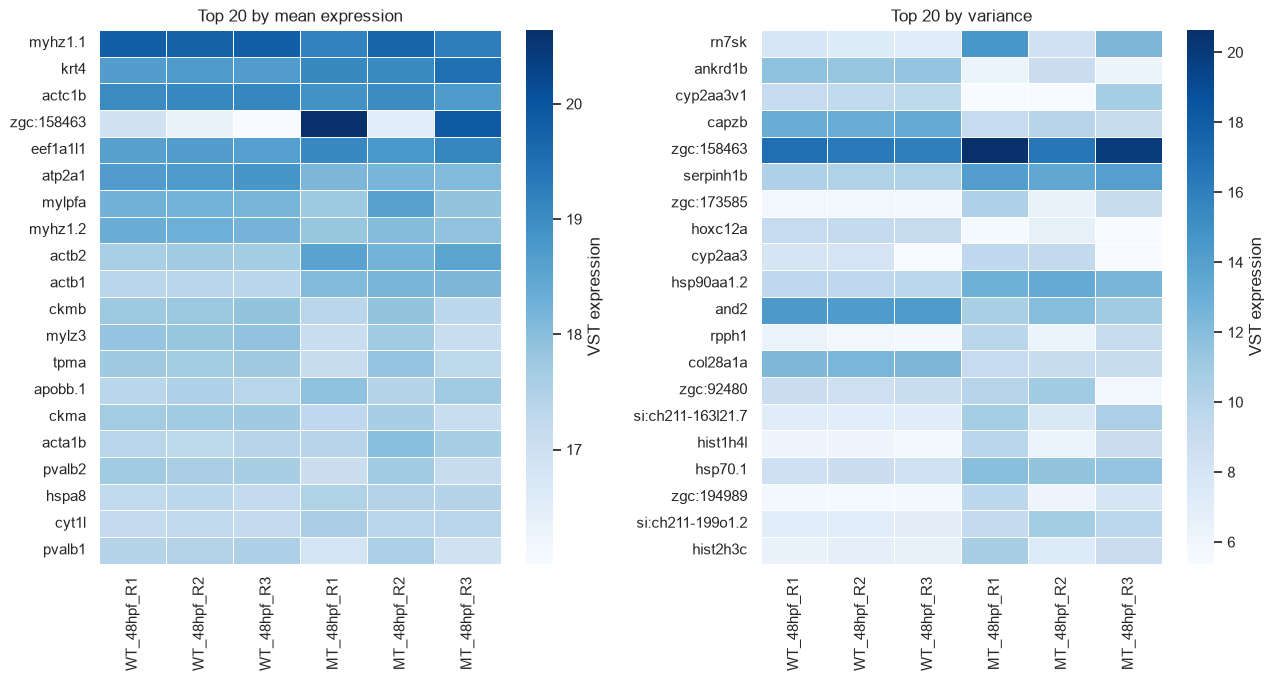

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))

for ax, genes, title in [
    (axes[0], top_mean, "Top 20 by mean expression"),
    (axes[1], top_var, "Top 20 by variance"),
]:
    sns.heatmap(vst[genes].T, cmap="Blues", ax=ax,
                cbar_kws={"label": "VST expression"}, linewidths=0.4)
    ax.set(title=title, xlabel="", ylabel="")

plt.tight_layout()
plt.show()

The variance panel shows a clear block structure: the three WT samples behave one
way and the three MT samples another. The mean panel mostly shows which genes are
abundant, which is far less interesting.

Scaling each gene to a z-score makes the pattern even clearer, because it removes
the overall expression level and leaves only the between-sample differences:

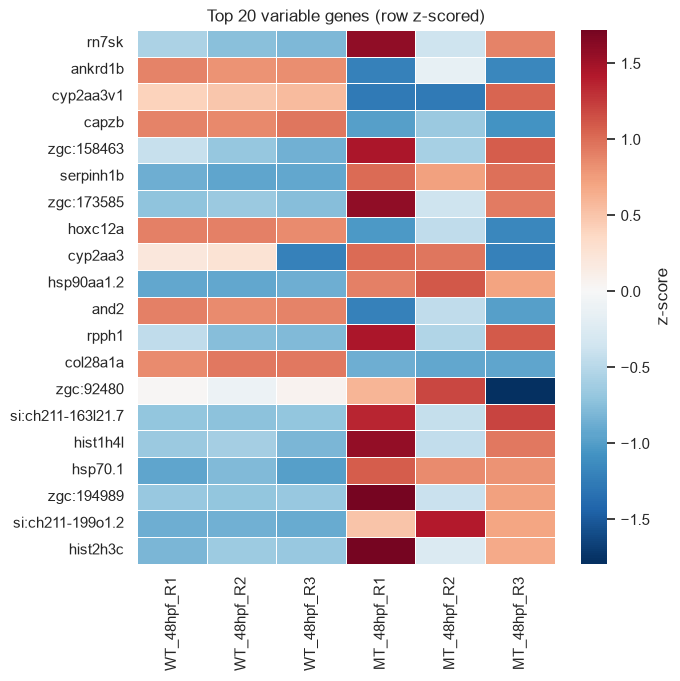

In [7]:
block = vst[top_var].T
zscored = block.sub(block.mean(axis=1), axis=0).div(block.std(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(zscored, cmap="RdBu_r", center=0,
            ax=ax, cbar_kws={"label": "z-score"}, linewidths=0.4)
ax.set(title="Top 20 variable genes (row z-scored)", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

## 5. Sample-to-sample distances

A pure quality check: do replicates of the same condition resemble each other
more than they resemble the other condition? If not, something went wrong in the
experiment.

> **Note:** we compute distances on the **VST** data. The R lesson uses
> `dist(t(assay(dds)))`, which operates on raw counts and is therefore dominated
> by the handful of most-expressed genes. VST is the better choice here.

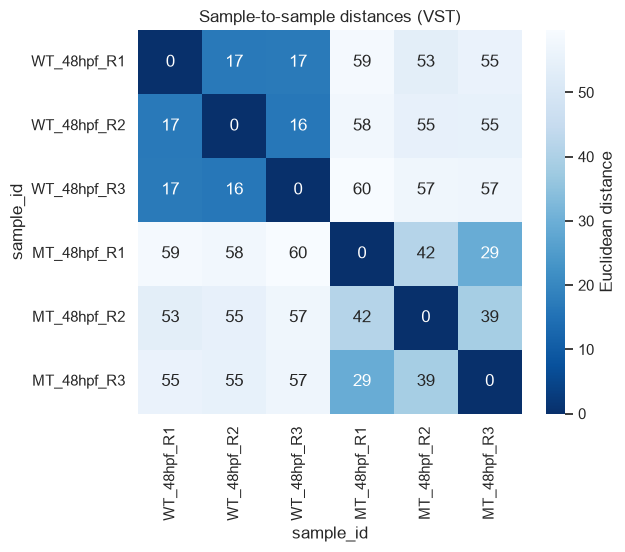

Zero on the diagonal (each sample against itself).
Within-group distances should be smaller than between-group distances.


In [8]:
from scipy.spatial.distance import pdist, squareform

dist = pd.DataFrame(
    squareform(pdist(vst.values, metric="euclidean")),
    index=vst.index, columns=vst.index,
)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(dist, cmap="Blues_r", annot=True, fmt=".0f",
            square=True, cbar_kws={"label": "Euclidean distance"}, ax=ax)
ax.set(title="Sample-to-sample distances (VST)")
plt.tight_layout()
plt.show()

print("Zero on the diagonal (each sample against itself).")
print("Within-group distances should be smaller than between-group distances.")

Clustering the same matrix makes the grouping explicit:

/Users/enrique/miniconda3/envs/zebraq-run/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/enrique/miniconda3/envs/zebraq-run/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


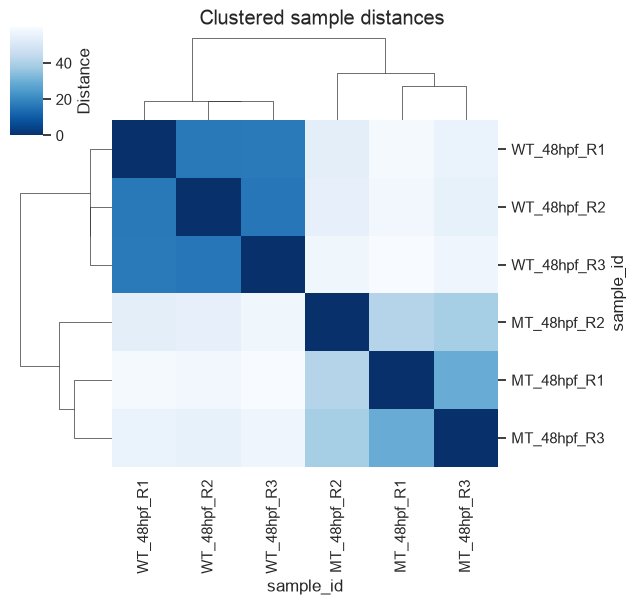

In [9]:
g = sns.clustermap(dist, cmap="Blues_r", figsize=(6.5, 6),
                   cbar_kws={"label": "Distance"})
g.figure.suptitle("Clustered sample distances", y=1.01)
plt.show()

## 6. Principal component analysis

PCA compresses thousands of genes into a couple of axes that capture as much of
the variation as possible. If the experiment worked, the first axis usually
separates the experimental groups.

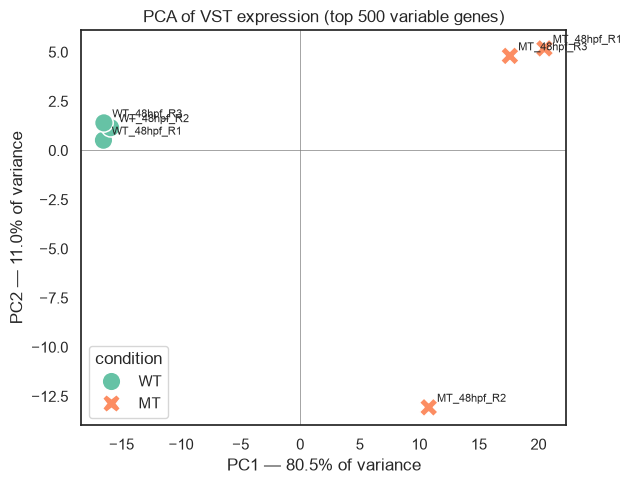

variance explained per component:
  PC1:  80.5%
  PC2:  11.0%
  PC3:   6.5%
  PC4:   1.2%


In [10]:
from sklearn.decomposition import PCA

# Convention: PCA on the most variable genes, samples as rows.
top500 = vst.var(axis=0).nlargest(500).index
X = vst[top500].values

pca = PCA(n_components=min(4, X.shape[0]))
coords = pca.fit_transform(X - X.mean(axis=0))
var_pct = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "sample": vst.index,
    "condition": metadata.loc[vst.index, "condition"].values,
})

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="condition",
                style="condition", s=180, palette="Set2", ax=ax)
for _, r in pca_df.iterrows():
    ax.annotate(r["sample"], (r["PC1"], r["PC2"]),
                xytext=(6, 4), textcoords="offset points", fontsize=8)
ax.set(title="PCA of VST expression (top 500 variable genes)",
       xlabel=f"PC1 — {var_pct[0]:.1f}% of variance",
       ylabel=f"PC2 — {var_pct[1]:.1f}% of variance")
ax.axhline(0, lw=0.5, c="grey"); ax.axvline(0, lw=0.5, c="grey")
plt.tight_layout()
plt.show()

print("variance explained per component:")
for i, v in enumerate(var_pct, 1):
    print(f"  PC{i}: {v:5.1f}%")

## 7. Volcano plot

The signature figure of differential expression: effect size on the x-axis,
statistical significance on the y-axis. Interesting genes are in the top corners
— large change *and* strong evidence.

R has `EnhancedVolcano`, which draws this in one call. We build it from scratch.
It is only a scatter plot with thresholds, and doing it manually means you can
change anything about it.

In [11]:
try:
    from adjustText import adjust_text
    HAVE_ADJUSTTEXT = True
except ImportError:
    HAVE_ADJUSTTEXT = False

LFC_CUT = 2.5     # fold-change threshold, matching the R lesson
P_CUT = 0.001     # p-value threshold, matching the R lesson

v = results.dropna(subset=["padj", "pvalue"]).copy()
v["neglog10p"] = -np.log10(v["pvalue"].clip(lower=1e-300))


def classify(row):
    big = abs(row["log2FoldChange"]) >= LFC_CUT
    sig = row["pvalue"] <= P_CUT
    if big and sig:
        return "significant & large change"
    if sig:
        return "significant only"
    if big:
        return "large change only"
    return "not significant"


v["group"] = v.apply(classify, axis=1)
print(v["group"].value_counts())

group
not significant               10115
significant only               3470
significant & large change      110
large change only                57
Name: count, dtype: int64


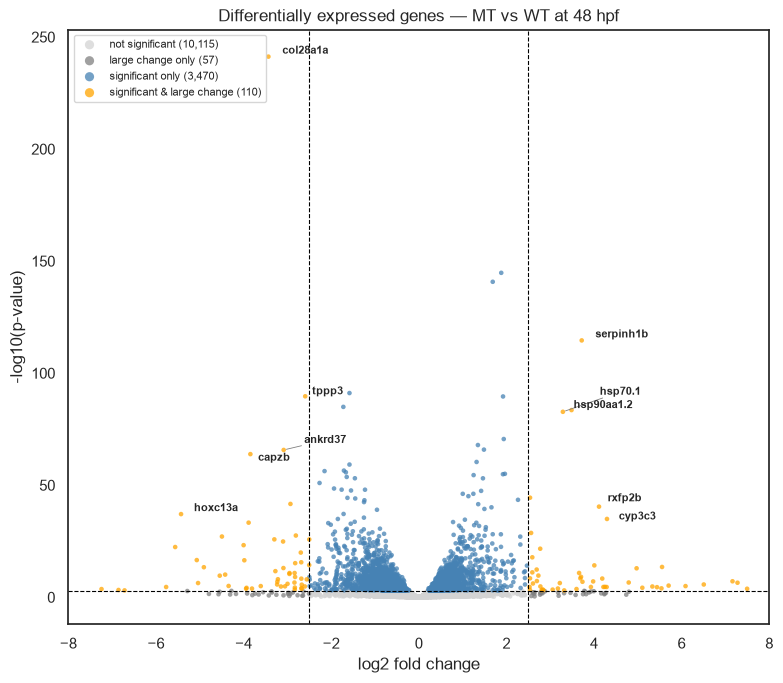

In [12]:
colors = {
    "not significant": "lightgrey",
    "large change only": "grey",
    "significant only": "steelblue",
    "significant & large change": "orange",
}

fig, ax = plt.subplots(figsize=(8, 7))

for grp, color in colors.items():
    sub = v[v["group"] == grp]
    ax.scatter(sub["log2FoldChange"], sub["neglog10p"],
               c=color, s=11, alpha=0.75, label=f"{grp} ({len(sub):,})",
               edgecolors="none")

ax.axhline(-np.log10(P_CUT), ls="--", c="black", lw=0.8)
ax.axvline(LFC_CUT, ls="--", c="black", lw=0.8)
ax.axvline(-LFC_CUT, ls="--", c="black", lw=0.8)

# label the ten most extreme genes
hits = v[v["group"] == "significant & large change"].copy()
hits["score"] = hits["neglog10p"] * hits["log2FoldChange"].abs()
labels = [
    ax.text(r["log2FoldChange"], r["neglog10p"], gene, fontsize=8, fontweight="bold")
    for gene, r in hits.nlargest(10, "score").iterrows()
]
if HAVE_ADJUSTTEXT and labels:
    adjust_text(labels, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=0.6))

ax.set(
    title=f"Differentially expressed genes — {TREATMENT} vs {REFERENCE} at 48 hpf",
    xlabel="log2 fold change",
    ylabel="-log10(p-value)",
    xlim=(-8, 8),
)
ax.legend(loc="upper left", frameon=True, fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

### How to read it

- **Right side**: higher in the mutant. **Left side**: higher in the wild type.
- **Higher up**: stronger statistical evidence.
- The dashed lines are the two thresholds we chose. They are conventions, not
  laws — state whatever you used when you publish.
- We plot raw `pvalue` on the y-axis because that is the convention (and what
  the R lesson does), but the gene lists you report should always be filtered on
  `padj`.

### 7.1 A cleaner variant using padj

Same plot, thresholded on the adjusted p-value — a more honest picture of what
survives multiple-testing correction.

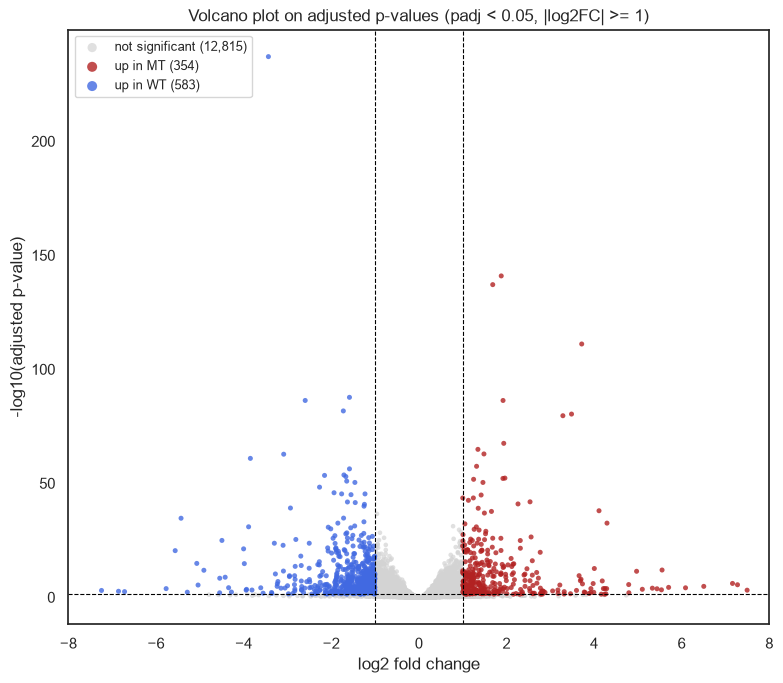

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))

v["neglog10padj"] = -np.log10(v["padj"].clip(lower=1e-300))
is_sig = (v["padj"] < ALPHA) & (v["log2FoldChange"].abs() >= 1)

ax.scatter(v.loc[~is_sig, "log2FoldChange"], v.loc[~is_sig, "neglog10padj"],
           c="lightgrey", s=11, alpha=0.7, edgecolors="none",
           label=f"not significant ({(~is_sig).sum():,})")
sig_up = is_sig & (v["log2FoldChange"] > 0)
sig_dn = is_sig & (v["log2FoldChange"] < 0)
ax.scatter(v.loc[sig_up, "log2FoldChange"], v.loc[sig_up, "neglog10padj"],
           c="firebrick", s=13, alpha=0.8, edgecolors="none",
           label=f"up in {TREATMENT} ({sig_up.sum():,})")
ax.scatter(v.loc[sig_dn, "log2FoldChange"], v.loc[sig_dn, "neglog10padj"],
           c="royalblue", s=13, alpha=0.8, edgecolors="none",
           label=f"up in {REFERENCE} ({sig_dn.sum():,})")

ax.axhline(-np.log10(ALPHA), ls="--", c="black", lw=0.8)
ax.axvline(1, ls="--", c="black", lw=0.8)
ax.axvline(-1, ls="--", c="black", lw=0.8)
ax.set(title=f"Volcano plot on adjusted p-values (padj < {ALPHA}, |log2FC| >= 1)",
       xlabel="log2 fold change", ylabel="-log10(adjusted p-value)", xlim=(-8, 8))
ax.legend(loc="upper left", frameon=True, fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

## 8. An MA plot

PyDESeq2 provides this one directly. It plots effect size against expression
level, and is the standard way to check that fold changes are not systematically
biased at low counts.

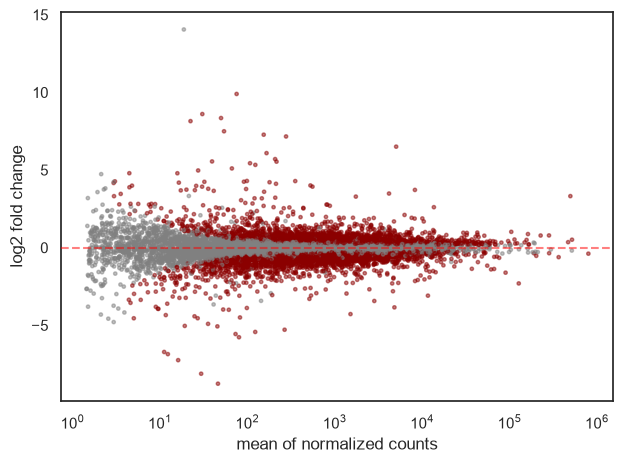

In [14]:
stat_res.plot_MA(s=6)

## 9. Exercises

1. Redraw the single-gene plot for the most significant gene in the table.
2. Rebuild the heatmap using the top 30 genes by absolute `log2FoldChange` among
   those with `padj < 0.05`. How does it compare to ranking by variance?
3. Colour the PCA by `replicate` instead of `condition`. Is there a batch effect?
4. Change the volcano thresholds to `padj < 0.01` and `|log2FC| >= 1`. How many
   genes qualify?
5. Add horizontal gene labels to the second volcano plot for the five most
   down-regulated genes.

### exercise 1
Find the gene with the smallest padj (most significant), then make a strip plot like we did for capzb.

Most significant gene: col28a1a (padj = 7.880e-238)
Least significant gene: si:dkey-72l14.7 (padj = 9.999e-01)


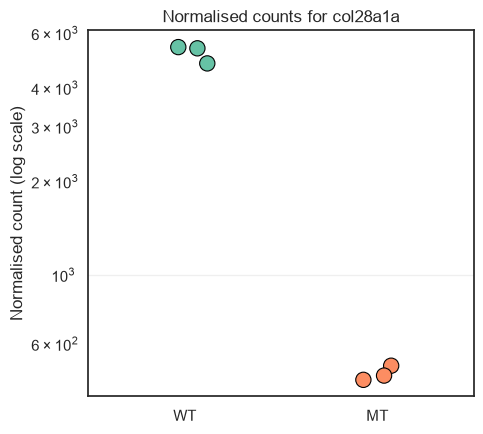

col28a1a: log2FC = -3.434, padj = 7.880e-238
  -> expression is 10.8x lower in MT


In [15]:
# Find the most significant gene (smallest padj)
most_significant_gene = results["padj"].idxmin()
print(f"Most significant gene: {most_significant_gene} (padj = {results.loc[most_significant_gene, 'padj']:.3e})")

#largest padj - just to see the other end of the spectrum
least_significant_gene = results["padj"].idxmax()
print(f"Least significant gene: {least_significant_gene} (padj = {results.loc[least_significant_gene, 'padj']:.3e})")

# Create the gene data frame
gene_df = pd.DataFrame({
    "count": normed[most_significant_gene],
    "condition": metadata.loc[normed.index, "condition"],
})

# Make the plot
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.stripplot(data=gene_df, x="condition", y="count", hue="condition",
              order=[REFERENCE, TREATMENT], palette="Set2",
              size=11, jitter=0.12, legend=False, edgecolor="black",
              linewidth=0.8, ax=ax)
ax.set_yscale("log")
ax.set(title=f"Normalised counts for {most_significant_gene}",
       xlabel="", ylabel="Normalised count (log scale)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Print stats
row = results.loc[most_significant_gene]
print(f"{most_significant_gene}: log2FC = {row['log2FoldChange']:.3f}, padj = {row['padj']:.3e}")
print(f"  -> expression is {2 ** abs(row['log2FoldChange']):.1f}x "
      f"{'lower' if row['log2FoldChange'] < 0 else 'higher'} in {TREATMENT}")

### exercise 2 
Rebuild the heatmap using the top 30 genes by absolute log2FoldChange among those with padj < 0.05

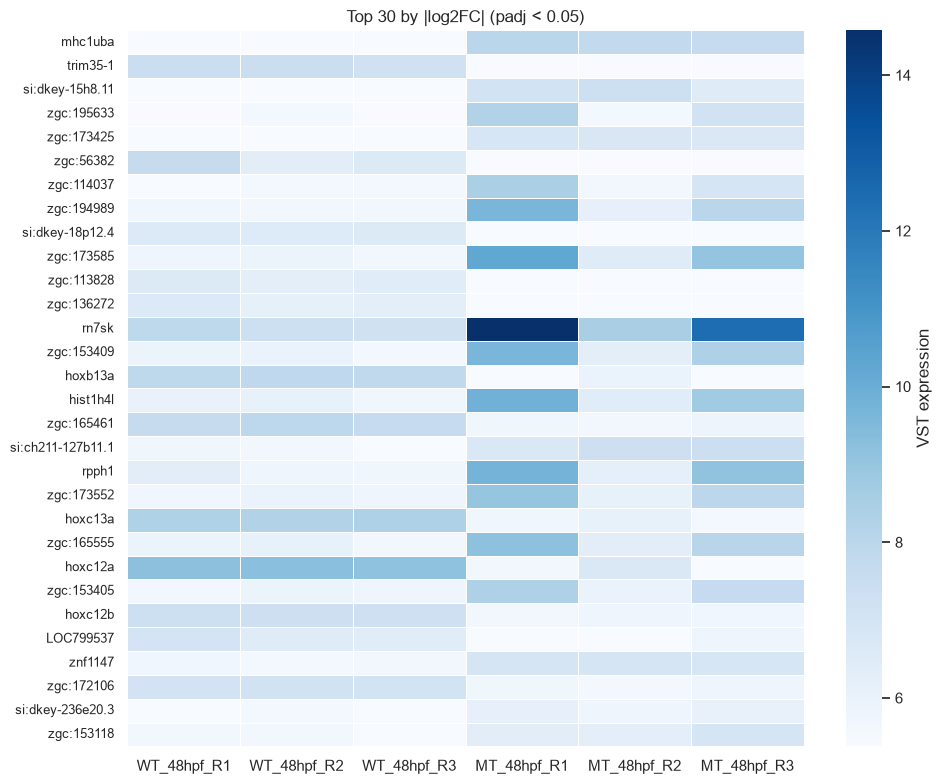

In [16]:
# Filter significant genes
sig_genes = results[results["padj"] < 0.05].copy()

# Sort by absolute log2FC and take top 30
top_lfc = sig_genes["log2FoldChange"].abs().nlargest(30).index

# Make the heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(vst[top_lfc].T, cmap="Blues", ax=ax,
            cbar_kws={"label": "VST expression"}, linewidths=0.4)
ax.set(title="Top 30 by |log2FC| (padj < 0.05)", xlabel="", ylabel="")
ax.set_yticklabels(top_lfc, rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### exercise 3 
re-run PCA but color points by replicate (e.g., S1, S2, S3, S4) instead of condition.

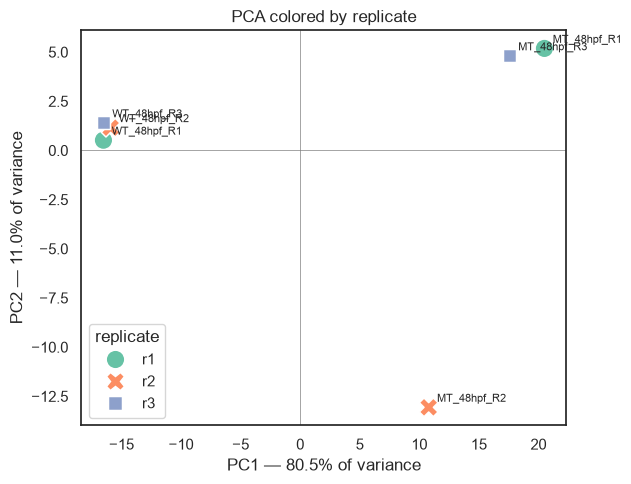

In [17]:
# Using the same PCA code, but color by replicate
top500 = vst.var(axis=0).nlargest(500).index
X = vst[top500].values

pca = PCA(n_components=min(4, X.shape[0]))
coords = pca.fit_transform(X - X.mean(axis=0))
var_pct = pca.explained_variance_ratio_ * 100

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "sample": vst.index,
    "replicate": metadata.loc[vst.index, "replicate"].values,  # ← key change
})

# Making the plot
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="replicate",
                style="replicate", s=180, palette="Set2", ax=ax)
for _, r in pca_df.iterrows():
    ax.annotate(r["sample"], (r["PC1"], r["PC2"]),
                xytext=(6, 4), textcoords="offset points", fontsize=8)
ax.set(title="PCA colored by replicate",
       xlabel=f"PC1 — {var_pct[0]:.1f}% of variance",
       ylabel=f"PC2 — {var_pct[1]:.1f}% of variance")
ax.axhline(0, lw=0.5, c="grey"); ax.axvline(0, lw=0.5, c="grey")
plt.tight_layout()
plt.show()

no batch effect if we compare it to the previous pca plot with conditions

### exercise 4
Change the volcano thresholds to padj < 0.01 and |log2FC| >= 1.

In [18]:
# Define new thresholds
ALPHA_NEW = 0.01
LFC_CUT_NEW = 1  # |log2FC| >= 1 → 2-fold change

# Create new significance mask
is_sig = (results["padj"] < ALPHA_NEW) & (results["log2FoldChange"].abs() >= LFC_CUT_NEW)

# Count
num_sig = is_sig.sum()
print(f"{num_sig:,} genes qualify with padj < {ALPHA_NEW} and |log2FC| >= {LFC_CUT_NEW}")

837 genes qualify with padj < 0.01 and |log2FC| >= 1


### exercise 5
Add horizontal gene labels to the second volcano plot for the five most down-regulated genes.

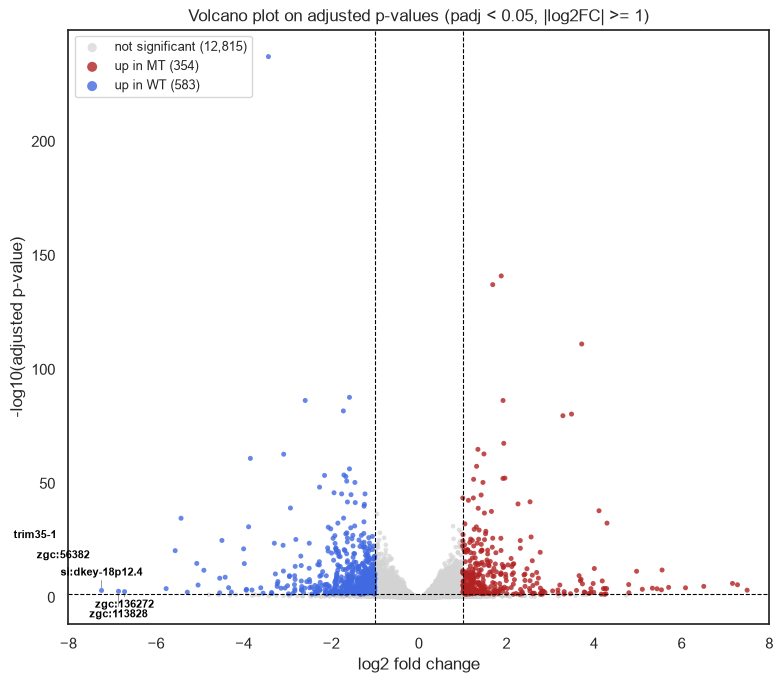

In [19]:
fig, ax = plt.subplots(figsize=(8, 7))

v["neglog10padj"] = -np.log10(v["padj"].clip(lower=1e-300))
is_sig = (v["padj"] < ALPHA) & (v["log2FoldChange"].abs() >= 1)

ax.scatter(v.loc[~is_sig, "log2FoldChange"], v.loc[~is_sig, "neglog10padj"],
           c="lightgrey", s=11, alpha=0.7, edgecolors="none",
           label=f"not significant ({(~is_sig).sum():,})")
sig_up = is_sig & (v["log2FoldChange"] > 0)
sig_dn = is_sig & (v["log2FoldChange"] < 0)
ax.scatter(v.loc[sig_up, "log2FoldChange"], v.loc[sig_up, "neglog10padj"],
           c="firebrick", s=13, alpha=0.8, edgecolors="none",
           label=f"up in {TREATMENT} ({sig_up.sum():,})")
ax.scatter(v.loc[sig_dn, "log2FoldChange"], v.loc[sig_dn, "neglog10padj"],
           c="royalblue", s=13, alpha=0.8, edgecolors="none",
           label=f"up in {REFERENCE} ({sig_dn.sum():,})")

ax.axhline(-np.log10(ALPHA), ls="--", c="black", lw=0.8)
ax.axvline(1, ls="--", c="black", lw=0.8)
ax.axvline(-1, ls="--", c="black", lw=0.8)

#5 most downregulated genes (lowest log2FC)
hits = v[ (v["padj"] < ALPHA) & (v["log2FoldChange"] <= -1)].copy()

# Lowest log2FoldChange means strongest down-regulation
top_down = hits.nsmallest(5, "log2FoldChange")

labels = [
    ax.text(
        row["log2FoldChange"],
        row["neglog10padj"],
        gene,
        fontsize=8,
        fontweight="bold",
        ha="center",
        va="center",
        color="black",
    )
    for gene, row in top_down.iterrows()
]

if HAVE_ADJUSTTEXT and labels:
    adjust_text(labels, ax=ax, force_text=1.0, force_static=0.8, force_pull=0.1, expand=(1.4, 1.8), only_move={
            "text": "y",
            "static": "y",
            "explode": "y",
            "pull": "y",
        },
        ensure_inside_axes=True, arrowprops=dict(arrowstyle="-", color="grey", lw=0.7, alpha=0.8,),
    )


ax.set(title=f"Volcano plot on adjusted p-values (padj < {ALPHA}, |log2FC| >= 1)",
       xlabel="log2 fold change", ylabel="-log10(adjusted p-value)", xlim=(-8, 8))
ax.legend(loc="upper left", frameon=True, fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()



Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


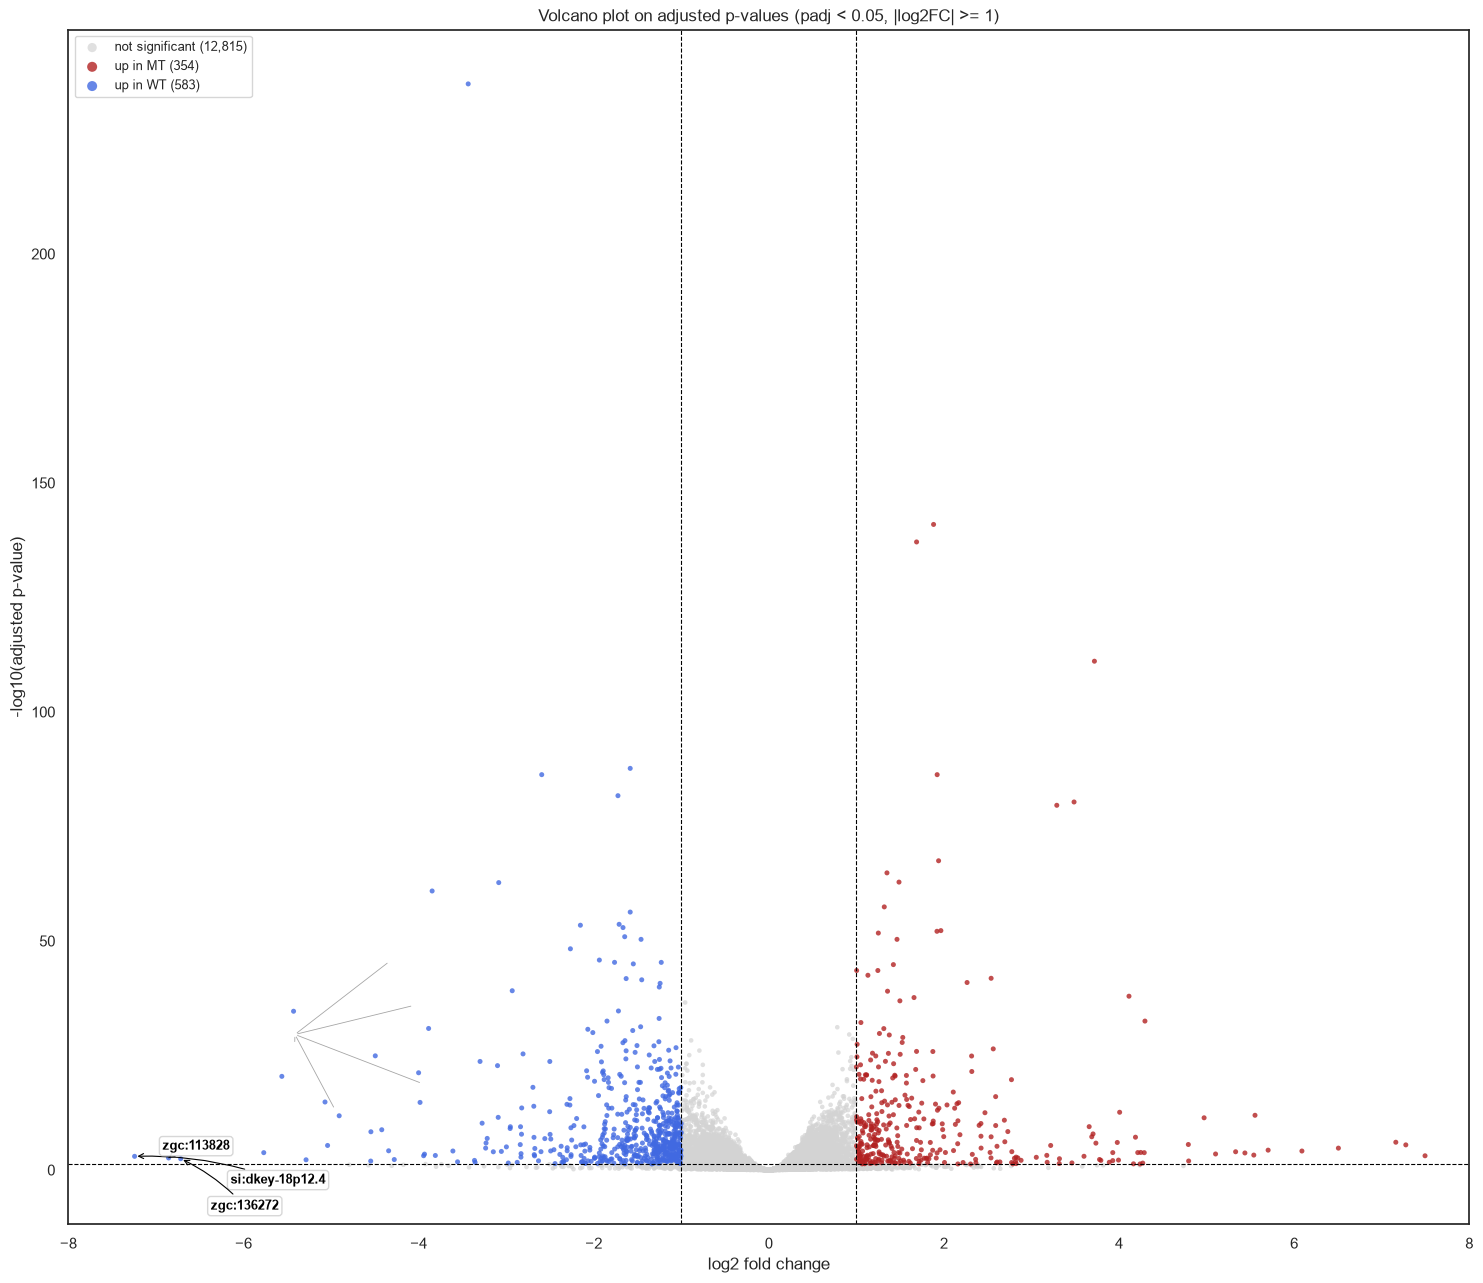

In [20]:
fig, ax = plt.subplots(figsize=(15, 13))

# 1. Prepare data
v["neglog10padj"] = -np.log10(v["padj"].clip(lower=1e-300))
is_sig = (v["padj"] < ALPHA) & (v["log2FoldChange"].abs() >= 1)

# 2. Plot non-significant genes
ax.scatter(v.loc[~is_sig, "log2FoldChange"], v.loc[~is_sig, "neglog10padj"],
           c="lightgrey", s=11, alpha=0.7, edgecolors="none",
           label=f"not significant ({(~is_sig).sum():,})")

# 3. Plot upregulated genes
sig_up = is_sig & (v["log2FoldChange"] > 0)
ax.scatter(v.loc[sig_up, "log2FoldChange"], v.loc[sig_up, "neglog10padj"],
           c="firebrick", s=13, alpha=0.8, edgecolors="none",
           label=f"up in {TREATMENT} ({sig_up.sum():,})")

# 4. Plot downregulated genes
sig_dn = is_sig & (v["log2FoldChange"] < 0)
ax.scatter(v.loc[sig_dn, "log2FoldChange"], v.loc[sig_dn, "neglog10padj"],
           c="royalblue", s=13, alpha=0.8, edgecolors="none",
           label=f"up in {REFERENCE} ({sig_dn.sum():,})")

# 5. Add threshold lines
ax.axhline(-np.log10(ALPHA), ls="--", c="black", lw=0.8)
ax.axvline(1, ls="--", c="black", lw=0.8)
ax.axvline(-1, ls="--", c="black", lw=0.8)

# 6. Find the 5 most down-regulated genes
hits = v[(v["padj"] < ALPHA) & (v["log2FoldChange"] <= -1)].copy()
top_down = hits.nsmallest(5, "log2FoldChange")  # Lowest log2FC = strongest down

# 7. Create labels with better styling
labels = []

for gene, row in top_down.iterrows():
    label = ax.annotate(
        gene,
        xy=(row["log2FoldChange"], row["neglog10padj"]),
        xytext=(20, 15),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        ha="center",
        va="bottom",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="lightgrey",
            alpha=0.9,
        ),
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=0.8,
            connectionstyle="arc3,rad=0.1",
        ),
    )
    labels.append(label)

# 8. Use adjust_text with better settings
if HAVE_ADJUSTTEXT and labels:
    adjust_text(
        labels,
        ax=ax,
        force_text=1.0,
        force_static=1.0,
        force_pull=0.5,
        expand=(1.4, 1.8),
        only_move={"text": "y", "static": "y", "explode": "y", "pull": "y"},
        ensure_inside_axes=True, 
        arrowprops=dict(
            arrowstyle="-",
            color="grey",
            lw=0.6,
            alpha=0.7,
            connectionstyle="arc3,rad=0"  # Straight arrow
        ),
        arrow_culling=True,
        min_arrow_dist=5,              # Minimum distance between arrows
        text_kwargs=dict(fontsize=9, fontweight="bold")
    )

# 9. Final plot settings
ax.set(title=f"Volcano plot on adjusted p-values (padj < {ALPHA}, |log2FC| >= 1)",
       xlabel="log2 fold change", ylabel="-log10(adjusted p-value)", xlim=(-8, 8))
ax.legend(loc="upper left", frameon=True, fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

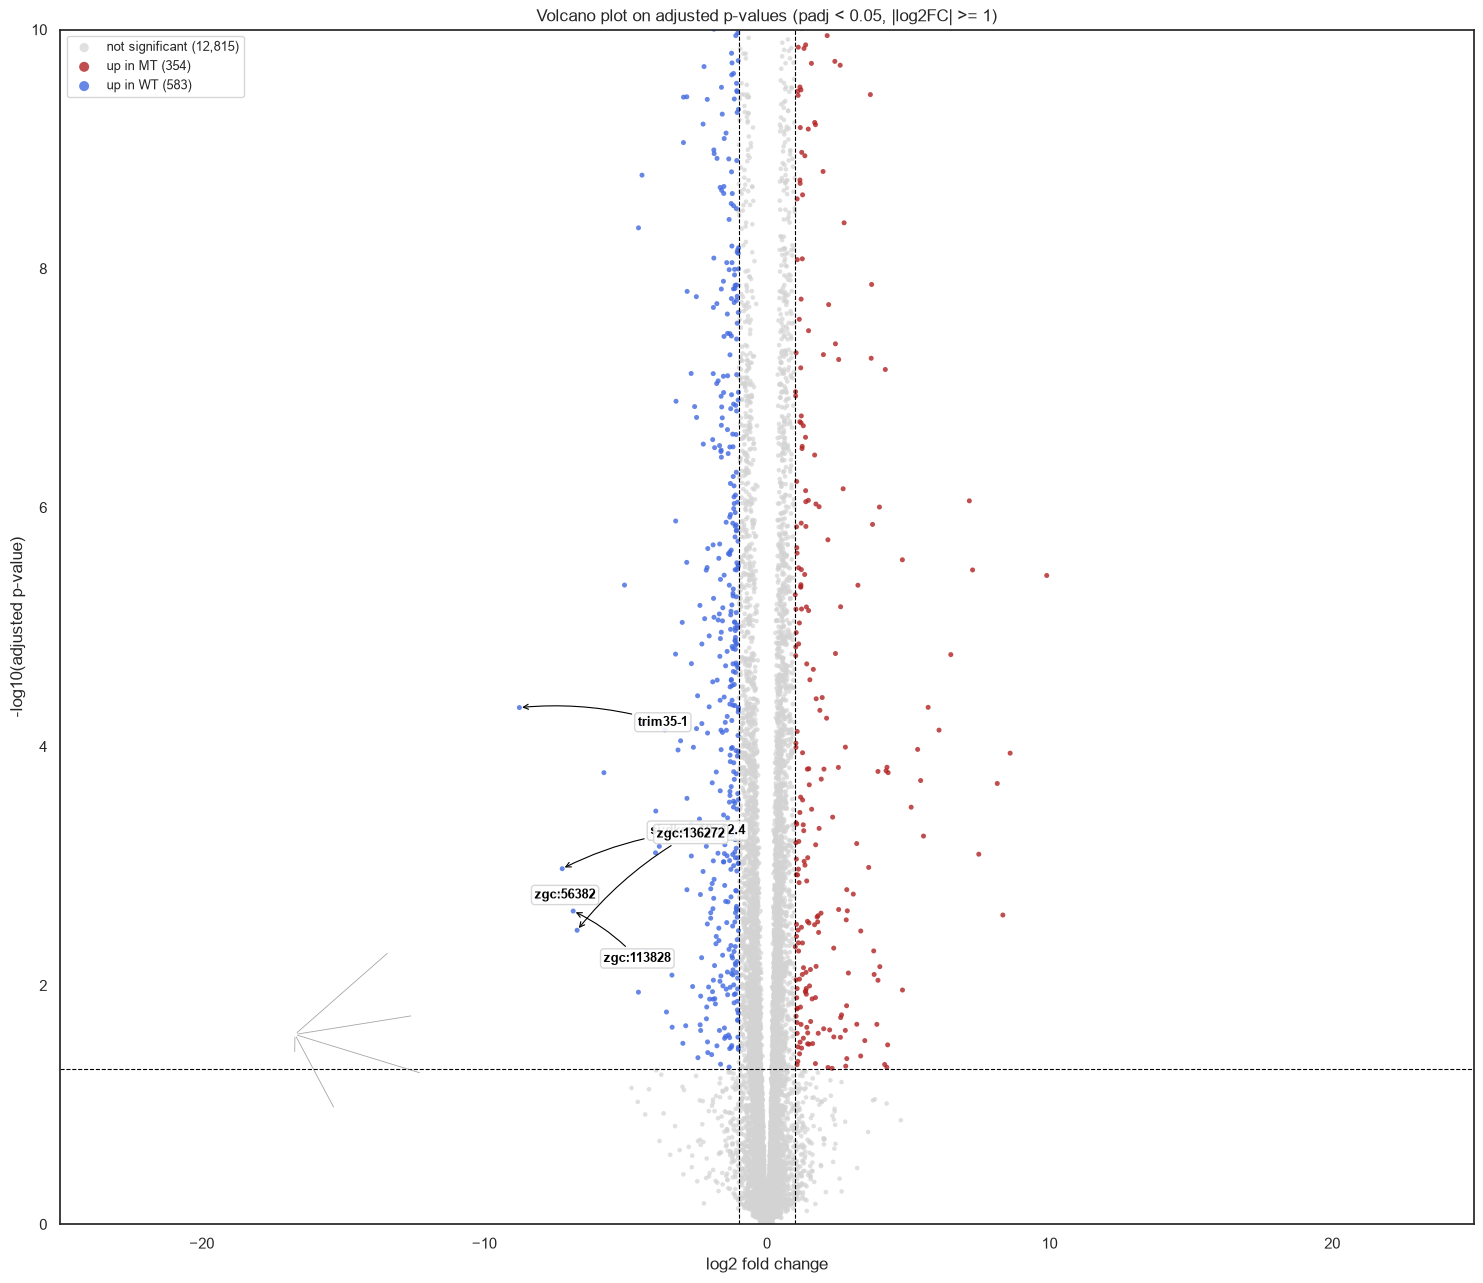

In [21]:
fig, ax = plt.subplots(figsize=(15, 13))

# 1. Prepare data
v["neglog10padj"] = -np.log10(v["padj"].clip(lower=1e-300))
is_sig = (v["padj"] < ALPHA) & (v["log2FoldChange"].abs() >= 1)

# 2. Plot non-significant genes
ax.scatter(v.loc[~is_sig, "log2FoldChange"], v.loc[~is_sig, "neglog10padj"],
           c="lightgrey", s=11, alpha=0.7, edgecolors="none",
           label=f"not significant ({(~is_sig).sum():,})")

# 3. Plot upregulated genes
sig_up = is_sig & (v["log2FoldChange"] > 0)
ax.scatter(v.loc[sig_up, "log2FoldChange"], v.loc[sig_up, "neglog10padj"],
           c="firebrick", s=13, alpha=0.8, edgecolors="none",
           label=f"up in {TREATMENT} ({sig_up.sum():,})")

# 4. Plot downregulated genes
sig_dn = is_sig & (v["log2FoldChange"] < 0)
ax.scatter(v.loc[sig_dn, "log2FoldChange"], v.loc[sig_dn, "neglog10padj"],
           c="royalblue", s=13, alpha=0.8, edgecolors="none",
           label=f"up in {REFERENCE} ({sig_dn.sum():,})")

# 5. Add threshold lines
ax.axhline(-np.log10(ALPHA), ls="--", c="black", lw=0.8)
ax.axvline(1, ls="--", c="black", lw=0.8)
ax.axvline(-1, ls="--", c="black", lw=0.8)

# 6. Find the 5 most down-regulated genes
hits = v[(v["padj"] < ALPHA) & (v["log2FoldChange"] <= -1)].copy()
top_down = hits.nsmallest(5, "log2FoldChange")  # Lowest log2FC = strongest down

# 7. Create labels with better styling
labels = []

for gene, row in top_down.iterrows():
    label = ax.annotate(
        gene,
        xy=(row["log2FoldChange"], row["neglog10padj"]),
        xytext=(20, 15),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        ha="center",
        va="bottom",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="lightgrey",
            alpha=0.9,
        ),
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=0.8,
            connectionstyle="arc3,rad=0.1",
        ),
    )
    labels.append(label)

# 8. Use adjust_text with better settings
if HAVE_ADJUSTTEXT and labels:
    adjust_text(
        labels,
        ax=ax,
        force_text=1.0,
        force_static=1.0,
        force_pull=0.5,
        expand=(1.4, 1.8),
        only_move={"text": "y", "static": "y", "explode": "y", "pull": "y"},
        ensure_inside_axes=True, 
        arrowprops=dict(
            arrowstyle="-",
            color="grey",
            lw=0.6,
            alpha=0.7,
            connectionstyle="arc3,rad=0"  # Straight arrow
        ),
        arrow_culling=True,
        min_arrow_dist=5,              # Minimum distance between arrows
        text_kwargs=dict(fontsize=9, fontweight="bold")
    )

# 9. Final plot settings
ax.set(
    title=f"Volcano plot on adjusted p-values (padj < {ALPHA}, |log2FC| >= 1)",
    xlabel="log2 fold change",
    ylabel="-log10(adjusted p-value)",
    xlim=(-25, 25),
    ylim=(0, 10)  # Add extra space on top for labels
)

ax.legend(loc="upper left", frameon=True, fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

## 10. Session information

In [22]:
import sys

from IPython.display import display

try:
    import session_info
except ModuleNotFoundError:
    # Not an error in your code: this kernel simply does not have session-info.
    # It ships with the course environment (setup/python/environment.yml).
    # The interpreter path below is the fastest way to see which Python the
    # notebook is actually using, which is usually the real problem.
    print("session-info is not installed in this kernel.")
    print("kernel:", sys.executable)
    print("See setup/python/README.md to select the ZebraQ environment.")
else:
    # display() rather than a bare call: inside try/except the returned HTML is
    # no longer the cell's last expression, so Jupyter would not render it.
    display(session_info.show())